# Week 1 — PyTorch basics: solubility regression on ESOL

Goal: build the full training pipeline by hand — no Lightning, no wandb. See `README.md` for the full brief and hard constraints.

Pipeline: SMILES -> Morgan fingerprint -> `Dataset` -> `DataLoader` -> `nn.Module` -> training loop -> validation loop -> checkpoint & test.

Each section below has a markdown cell describing the step and a code cell with a stub. Fill in the `TODO`s yourself.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

from sklearn.metrics import mean_absolute_error

from rdkit import Chem

from datasets import load_dataset

# random seed and set it for numpy + torch, so your run is reproducible.
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

## 1. Load the ESOL dataset

Search the HuggingFace Hub (https://huggingface.co/datasets) for an ESOL / MoleculeNet aqueous-solubility dataset. Check the dataset card so you know what the columns actually are before you write code against them.

Once loaded, inspect it: how many rows, what are the column names, which column is the SMILES string, which column is the solubility target (and what units / scale is it on — raw or log solubility)?

In [53]:
# load dataset split into folds
ds_train = load_dataset("HR-machine/ESol", split="train").to_pandas()
ds_val = load_dataset("HR-machine/ESol", split="validation").to_pandas()
ds_test = load_dataset("HR-machine/ESol", split="test").to_pandas()
# inspect fold shapes, also look at one row to see column names and values.
print(f"train shape: {ds_train.shape}")
print(f"validation shape: {ds_val.shape}")
print(f"test shape: {ds_test.shape}")
print("="*10)
print("visualize dataset")
ds_train

train shape: (902, 10)
validation shape: (113, 10)
test shape: (113, 10)
visualize dataset


,smiles,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
0,CC(C)=CCCC(C)=CC(=O),citral,-2.579,1,152.237,0,0,4,17.07,-2.06
1,CCCC=C,1-Pentene,-2.010,1,70.135,0,0,2,0.00,-2.68
2,CCCCCCCCCCCCCC,Tetradecane,-5.450,1,198.394,0,0,11,0.00,-7.96
3,CC(C)Cl,2-Chloropropane,-1.585,1,78.542,0,0,0,0.00,-1.41
4,CCC(C)CO,2-Methylbutanol,-1.027,1,88.150,1,0,2,20.23,-0.47
...,...,...,...,...,...,...,...,...,...,...
897,CC(=O)OCC(=O)C3(O)CCC4C2CCC1=CC(=O)CCC1(C)C2C(...,cortisone acetate,-3.426,1,402.487,1,4,3,97.74,-4.21
898,c3ccc2nc1ccccc1cc2c3,Acridine,-3.846,2,179.222,0,3,0,12.89,-3.67
899,Nc2cccc3nc1ccccc1cc23,1-aminoacridine,-3.542,1,194.237,1,3,0,38.91,-4.22
900,C1CCCCCC1,Cycloheptane,-2.916,2,98.189,0,1,0,0.00,-3.51


## 2. Featurize: SMILES -> Morgan fingerprint

Write a function that turns the SMILES strings into a fixed-length numeric vector using RDKit's Morgan fingerprint.

Then apply it across the whole dataset to build your feature matrix `X` and target vector `y`. Watch for SMILES strings that fail to parse.

In [ ]:
fpgen = Chem.rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=256)

def smiles_to_morgan_fp(smiles) -> list:
    """Convert SMILES to a Morgan fingerprint bit vectors."""
    mols = Chem.MolFromSmiles(smiles)
    if mols is not None:
        return fpgen.GetFingerprintAsNumPy(mols)
    return None  # unparseable SMILES -> dropped below

ds_train['morgan_fp'] = ds_train['smiles'].apply(smiles_to_morgan_fp)
ds_val['morgan_fp'] = ds_val['smiles'].apply(smiles_to_morgan_fp)
ds_test['morgan_fp'] = ds_test['smiles'].apply(smiles_to_morgan_fp)

# drop any rows where RDKit couldn't parse the SMILES
ds_train = ds_train.dropna(subset=['morgan_fp'])
ds_val = ds_val.dropna(subset=['morgan_fp'])
ds_test = ds_test.dropna(subset=['morgan_fp'])

print(len(ds_train),len(ds_val),len(ds_test))

## 3. Train / validation split

Split `X`/`y` into a training set and a validation set. Think about the split fraction and whether you need to set a random state for reproducibility.

- the ESol data set is already loaded from huggingface with fold splits so no need for this step

## 4. `Dataset` and `DataLoader`

Write a custom `torch.utils.data.Dataset` that wraps your feature/target arrays. It needs `__len__` and `__getitem__`. Think about dtypes: what dtype does `nn.Linear` expect, and what dtype are your fingerprint bits / targets in right now?

In [ ]:
class ESOLDataset(Dataset):
    def __init__(self, dataset: pd.DataFrame):
        # nn.Linear needs float32 inputs, fingerprints come back as uint8 bits
        self.X = torch.from_numpy(np.stack(dataset['morgan_fp'])).to(torch.float32)
        # unsqueeze(1) so y is (N, 1), matching the model's (N, 1) output shape
        self.y = torch.from_numpy(np.stack(dataset['ESOL predicted log solubility in mols per litre'])).to(torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x_i = self.X[idx]
        y_i = self.y[idx]
        return x_i, y_i

train_dataset = ESOLDataset(ds_train)
val_dataset = ESOLDataset(ds_val)
test_dataset = ESOLDataset(ds_test)

# shuffle train each epoch so batches aren't always in the same order;
# val/test order doesn't affect anything, so no need to shuffle them
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, BATCH_SIZE, shuffle=False)

## 5. Model — `nn.Module`

A small MLP: input layer sized to your fingerprint length, two or three hidden layers, and a single output for the regression target. Think about what (if any) activation belongs on the output layer for a regression task, versus a classification one.

In [ ]:
class SolubilityRegressor(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = None):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Dropout(p=0.2),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Dropout(p=0.2),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)  # single continuous output, no activation - regression, not classification
        )

    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return logits

model = SolubilityRegressor(256, 32)
print(model)

## 6. Training loop (with validation + checkpointing)

Pick a loss function appropriate for regression, and an optimizer. Write the loop: for each epoch, iterate over `train_loader`, do the forward pass, compute loss, backward, step, zero gradients, and track the average training loss per epoch.

Right after training each epoch, run one pass over `val_loader` (no gradient updates) and track the average validation loss.

While you're at it: whenever val loss beats the best you've seen so far, save a checkpoint (model `state_dict`, optimizer `state_dict`, epoch number, and the best val loss itself) to `CHECKPOINT_PATH`.

In [ ]:
# loss function for regression.
loss_fn = nn.MSELoss()

# optimizer and learning rate.
optimizer = optim.AdamW(model.parameters(), lr=0.001)

CHECKPOINT_PATH = "checkpoint.pt"
N_EPOCHS = 10
train_losses = []
best_val_loss = float("inf")  # tracks the best val loss seen so far, for checkpointing

def train_loop(model, dataloader, loss_fn, optimizer) -> float:
    """Run one training epoch, return the average training loss."""
    model.train()
    n_batches = len(dataloader)
    train_loss = 0

    for _, (X, y) in enumerate(dataloader):
        
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
        train_loss += loss.item()
    
    train_loss /= n_batches  # average per-batch loss across the epoch

    return train_loss

def val_loop(model, dataloader, loss_fn) -> tuple[float, float]:
    """Run one validation epoch, return the average validation loss."""
    model.eval()  # turns off dropout for evaluation
    n_batches = len(dataloader)
    val_loss = 0
    mae_value = 0

    with torch.no_grad():  # no gradients needed, we're not training here
        for X, y in dataloader:
            pred = model(X)
            val_loss += loss_fn(pred, y).item()
            mae_value += mean_absolute_error(pred, y)

    val_loss /= n_batches
    mae_value /= n_batches

    return val_loss, mae_value

# loop for N_EPOCHS, call train_loop, append to train_losses, print progress.
for t in range(N_EPOCHS):
    print("\n-------------------------------")
    train_epoch_loss = train_loop(model, train_loader, loss_fn, optimizer)
    val_epoch_loss, mae_value = val_loop(model, val_loader, loss_fn)
    train_losses.append([t, train_epoch_loss, val_epoch_loss, mae_value])
    print(f"Epoch {t+1}\ntrain loss: {train_epoch_loss}\nval loss: {val_epoch_loss}\nMAE: {mae_value}")

    # save a checkpoint whenever val loss improves - keeps the best model on
    # disk instead of whatever the last epoch happened to produce
    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        checkpoint = {
            "epoch": t+1,
            "val_loss": val_epoch_loss,
            "mae": mae_value,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict()  
        }
        torch.save(checkpoint, CHECKPOINT_PATH)

print("Done!")


## 7. Visualize training curves

Plot train, val, and MAE curves. Does it look like it's still improving, plateaued, or overfitting? Take this — and anything that broke along the way — into `REFLECTION.md`.

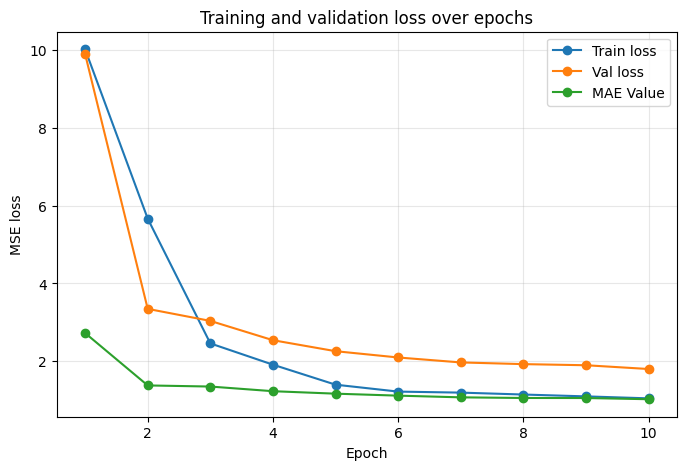

In [128]:
epochs, train_vals, val_vals, mae_values = zip(*train_losses)
epochs = [e + 1 for e in epochs]  # 1-indexed for display

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_vals, label="Train loss", marker="o")
plt.plot(epochs, val_vals, label="Val loss", marker="o")
plt.plot(epochs, mae_values, label="MAE Value", marker="o")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training and validation loss over epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Load best checkpoint & final test evaluation

Load your saved checkpoint back into a *fresh* model instance and confirm it reproduces the val loss/MAE you logged when it was saved.

Then run the model on the test dataset to find the loss and mae matric values.

In [ ]:
# load weights of best epoch into new model (named best model)
checkpoint = torch.load(CHECKPOINT_PATH)
checkpoint_weights = checkpoint["model_state_dict"]
best_model = SolubilityRegressor(256, 32)
best_model.load_state_dict(checkpoint_weights)
val_epoch_loss, mae_value = val_loop(best_model, val_loader, loss_fn)
# round-trip check: reloaded model should reproduce the exact val metrics we saved
assert math.isclose(val_epoch_loss, checkpoint["val_loss"], rel_tol=1e-6)
assert math.isclose(mae_value, checkpoint["mae"], rel_tol=1e-6)
print(f"best epoch: {checkpoint['epoch']}")

# run best model on test_loader - the one-shot, final, unbiased evaluation
test_epoch_loss, test_mae_value = val_loop(best_model, test_loader, loss_fn)
print(f"=====test evalutation=====\nloss: {test_epoch_loss}\nmae: {test_mae_value}")

## 9. See it in action — sample predictions

A qualitative sanity check, separate from the aggregate metrics above: pull a handful of real molecules from the test set, run them through the best checkpointed model, and look at predicted vs. actual log solubility side by side.

In [130]:
best_model.eval()

sample = ds_test.sample(10, random_state=SEED).reset_index(drop=True)
X_sample = torch.from_numpy(np.stack(sample['morgan_fp'])).to(torch.float32)

with torch.no_grad():
    preds = best_model(X_sample).squeeze(1)

comparison = pd.DataFrame({
    "Compound ID": sample["Compound ID"],
    "SMILES": sample["smiles"],
    "Actual log solubility": sample["measured log solubility in mols per litre"],
    "Predicted log solubility": preds.numpy(),
})
comparison["Abs error"] = (comparison["Actual log solubility"] - comparison["Predicted log solubility"]).abs()

comparison

,Compound ID,SMILES,Actual log solubility,Predicted log solubility,Abs error
0,pregnenolone,CC(=O)C3CCC4C2CC=C1CC(O)CCC1(C)C2CCC34C,-4.650,-4.129616,0.520384
1,Acenapthylene,C1=Cc2cccc3cccc1c23,-3.960,-2.961815,0.998185
2,Dienochlor,ClC1=C(Cl)C(Cl)(C(=C1Cl)Cl)C2(Cl)C(=C(Cl)C(=C2...,-7.278,-2.695956,4.582044
3,"7,12-Dimethylbenz(a)anthracene",Cc1c2ccccc2c(C)c3ccc4ccccc4c13,-7.020,-4.400883,2.619117
4,Methoxsalen,COc2c1occc1cc3ccc(=O)oc23,-3.664,-3.181725,0.482275
5,Aldrin,ClC1=C(Cl)C2(Cl)C3C4CC(C=C4)C3C1(Cl)C2(Cl)Cl,-6.307,-4.526650,1.780350
6,Triazolam,Cc3nnc4CN=C(c1ccccc1Cl)c2cc(Cl)ccc2n34,-4.090,-5.858270,1.768270
7,Equilin,CC34CCC1C(=CCc2cc(O)ccc12)C3CCC4=O,-5.282,-3.450937,1.831063
8,Carboxin,CC1=C(SCCO1)C(=O)Nc2ccccc2,-3.140,-1.846895,1.293105
9,piroxicam,CN2C(=C(O)c1ccccc1S2(=O)=O)C(=O)Nc3ccccn3,-4.160,-2.689834,1.470166
